In [ ]:
import warnings

warnings.filterwarnings("ignore")

import os  
import sys
parent =  os.path.join(os.getcwd(), 'package', 'synthdid')
dir = os.path.dirname(parent)
sys.path.append(dir)

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from tqdm import tqdm

from synthdid.model import SynthDID

path = os.path.join(os.getcwd(), 'final_clean')
path2 = os.path.join(os.getcwd(), 'final_LaTeX')

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv(path + "/patents_dataset.csv")
df.head()

,country,year,brevets,NX,salary,gdp,pop,cho,ppa,public_spending,IDE
0,AUT,1996,9.610726,0.201729,-0.006855,-0.169498,8.982061,0.215484,-0.004415,0.041468,1.406747
1,AUT,1997,9.652395,-0.428677,-0.008273,-0.031561,8.983194,-0.025326,-0.002641,0.016204,-0.311722
2,AUT,1998,9.730146,-0.104218,0.031968,0.627749,8.984291,0.065154,-0.009559,0.041098,0.670037
3,AUT,1999,9.965429,-0.005612,0.022200,0.077027,8.986237,-0.143091,0.001231,0.048799,-0.346392
4,AUT,2000,10.214788,-0.124520,0.003100,-0.152157,8.988642,-0.002762,-0.017752,0.052545,2.147245


In [6]:
df = df[['year', 'country', 'brevets', 'gdp', 'pop', 'NX', 'public_spending']]

In [7]:
df['country_code'] = pd.factorize(df['country'])[0] 

codes_df = df.copy()

def code(codes=codes_df) -> None:
    """
    Print country codes for AUT, FIN, and IRL, and list unique countries.
    """
    print("AUT code is = ", df[df['country'] == 'AUT']['country_code'].head(1).to_list(), "\n")
    print("FIN code is = ", df[df['country'] == 'FIN']['country_code'].head(1).to_list(), "\n")
    print("IRL code is = ", df[df['country'] == 'IRL']['country_code'].head(1).to_list(), "\n")
    print("CHE code is = ", df[df['country'] == 'CHE']['country_code'].head(1).to_list(), "\n")
    print("SWE code is = ", df[df['country'] == 'SWE']['country_code'].head(1).to_list(), "\n")
    
code()

AUT code is =  [0] 

FIN code is =  [1] 

IRL code is =  [2] 

CHE code is =  [3] 

SWE code is =  [4] 



In [8]:
df =df.rename(columns={'country_code': 'state'})
df

,year,country,brevets,gdp,pop,NX,public_spending,state
0,1996,AUT,9.610726,-0.169498,8.982061,0.201729,0.041468,0
1,1997,AUT,9.652395,-0.031561,8.983194,-0.428677,0.016204,0
2,1998,AUT,9.730146,0.627749,8.984291,-0.104218,0.041098,0
3,1999,AUT,9.965429,0.077027,8.986237,-0.005612,0.048799,0
4,2000,AUT,10.214788,-0.152157,8.988642,-0.124520,0.052545,0
...,...,...,...,...,...,...,...,...
110,2014,SWE,7.494986,1.017870,9.179575,-0.646275,0.005178,4
111,2015,SWE,7.478735,0.920991,9.190055,-0.311103,0.021874,4
112,2016,SWE,7.536897,-0.467196,9.202619,-2.022283,0.043571,4
113,2017,SWE,7.431892,-0.223252,9.216094,-0.251122,0.004144,4


In [9]:
df_ = df.pivot(index='state', columns="year")['brevets'].T
df_.head()

state,0,1,2,3,4
year,,,,,
1996,9.610726,8.755580,6.154858,7.651596,8.483636
1997,9.652395,8.545975,6.309918,7.577634,8.513988
1998,9.730146,7.994295,6.364751,7.434848,8.442039
1999,9.965429,7.865188,6.248043,7.386471,8.498214
2000,10.214788,7.959975,6.214608,7.372118,8.525955


In [10]:
PRE_TEREM = [1999, 2015]
POST_TEREM = [2016, 2019]
TREATMENT = [2]  # "Treated country

sdid = SynthDID(df_, PRE_TEREM, POST_TEREM, TREATMENT)

In [11]:
sdid.fit(zeta_type="base", sparce_estimation=True)
hat_omega_simple = sdid.estimated_params(model="sc")
# hat_omega_elastic = sdid.estimated_params(model="ElasticNet")

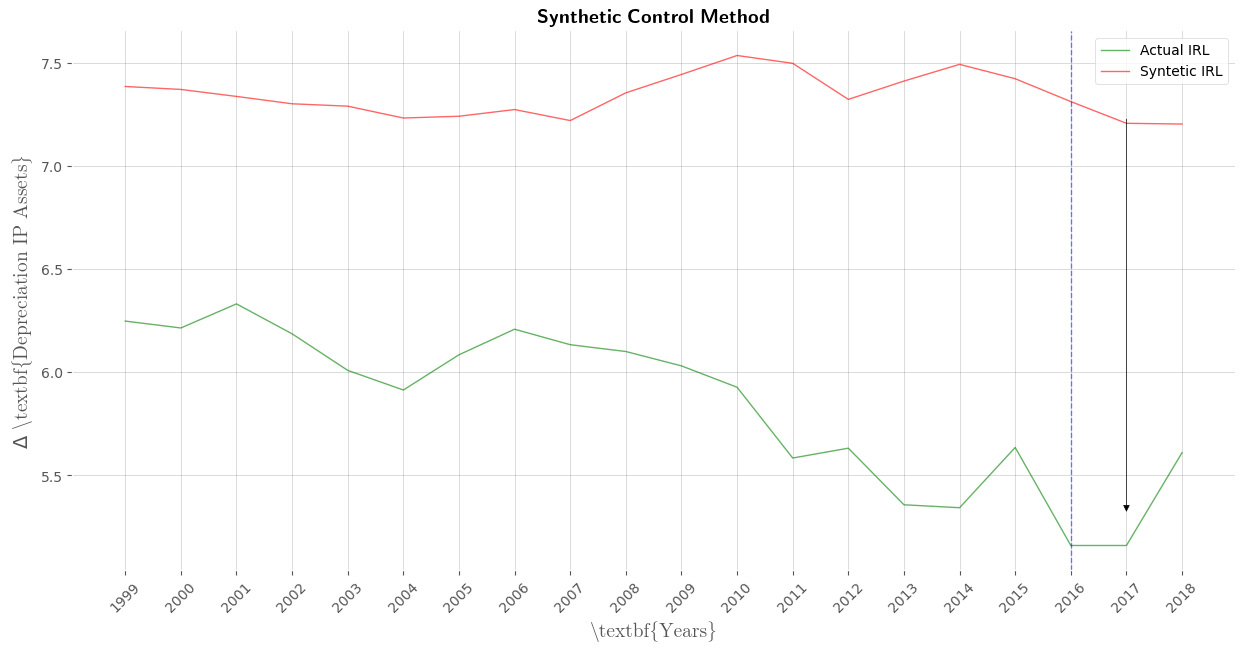

------------------------------------------------------------
Syntetic Control Method

point estimate: -1.933
-1.9325490523149158


In [14]:
sdid.plot(model="sc")
# sdid.plot(model="did")

summary = sdid.summary(model="sc")
print(summary)

In [15]:
predicted = sdid.sdid_trajectory()
observed = sdid.target_y()
rmspe = ((observed - predicted) ** 2).mean() ** 0.5
print(f"RMSPE : {rmspe}")

RMSPE : 1.8937997170576786


In [16]:
hat_omega_sdid, _ = sdid.estimated_params()
print(hat_omega_sdid)
# Appeler la méthode comparison_plot
# sdid.comparison_plot(model="all", figsize=(10, 7))
weights_scm = sdid.hat_omega_ADH
weights_scm_df = pd.DataFrame(weights_scm, columns=['weights'])
weights_scm_df['weights'] = weights_scm_df['weights'].apply(lambda x: f"{x:.2e}")
# weights_scm_df.T.to_latex("/Users/jey/Desktop/Datascience/Latex/sdid/Brevets_weights_scm.tex")
print("\n", "weights_scm", weights_scm)
df_.head()

    features  sdid_weight
0          0        0.181
1          1        0.306
2          3        0.424
3          4        0.089
4  intercept       -1.837

 weights_scm [3.38530657e-15 0.00000000e+00 1.00000000e+00 2.62147225e-15]


state,0,1,2,3,4
year,,,,,
1996,9.610726,8.755580,6.154858,7.651596,8.483636
1997,9.652395,8.545975,6.309918,7.577634,8.513988
1998,9.730146,7.994295,6.364751,7.434848,8.442039
1999,9.965429,7.865188,6.248043,7.386471,8.498214
2000,10.214788,7.959975,6.214608,7.372118,8.525955


In [21]:
weights_sc = sdid.hat_omega_ADH  # Poids SC (Synthetic Control)
control_units = sdid.control     # Liste des colonnes des unités de contrôle

weights_sc_dict = {unit: weight for unit, weight in zip(control_units, weights_sc)}

weights_sc_df = pd.DataFrame({'state': control_units, 'weight_sc': weights_sc})
print(weights_sc_df)



   state     weight_sc
0      0  3.385307e-15
1      1  0.000000e+00
2      3  1.000000e+00
3      4  2.621472e-15


In [19]:
tau_hat = sdid.hat_tau(model="sc")

b = {
    "RMSPE" : rmspe,
    "tau_hat" : tau_hat
}
b = pd.DataFrame(b, index=[0])

weights_sc_df.iloc[0,0:1] = 'AUT'
weights_sc_df.iloc[1,0:1] = 'FIN'
weights_sc_df.iloc[2,0:1] = 'CHE'
weights_sc_df.iloc[3,0:1] = 'SWE'

weights_sc_df

,state,weight_sc
0,AUT,3.385307e-15
1,FIN,0.000000e+00
2,CHE,1.000000e+00
3,SWE,2.621472e-15


In [ ]:
# b.to_latex(path2 + "/tau_hat_patents.tex", float_format="%.2e")
# weights_sc_df.to_latex(path2 + "/weights_patents.tex", float_format="%.2e")